# 04 — Feature engineering

## Purpose

This notebook builds the modeling feature table for the osteoporosis case-control data. It takes imputation 1 of `osteo_impute_final.csv`, drops 4 strata (61,026 rows, 30,513 matched pairs), recodes the demographic variables (`Age_combine`, `Race_Cat_combine`, `sex`), loads the feature groups from `config_ml.yaml`, replaces the calcium and sodium lab columns with `_measured` (presence) and `_decile` columns, checks lab missingness by case/control status, and saves the result to `osteo_features.csv`.

## Contents

1. Load data
2. Feature Engineering for demographics variables
    - 2.1 Age
        - 2.1.1 Compare "age_group" vs "age_enc_Date1"
        - 2.1.2 Regroup "Age_Enc_Date1" into "Age_combine"
    - 2.2 RACE
    - 2.3 SEX
    - 2.4 Check again for demographic vars
3. Variable list
4. Data preprocessing for numeric variables
    - 4.1 Lab test coverage: pre-index vs full record
5. Check distribution of calcium_sodium values
6. Proportion of Missingness on case vs control
6. Save features

# 1. Load data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
from statsmodels.discrete.conditional_models import ConditionalLogit

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SOURCE_FILE = DATA_DIR / "osteo_impute_final.csv"

In [3]:
import numpy as np
import pandas as pd
import yaml

df = pd.read_csv(
    SOURCE_FILE,
    low_memory=False,
)
cfg = yaml.safe_load(open("config.yaml"))

df["osteo_label"] = (df["Group"] == "Case").astype(int)
one = df[df["_Imputation_"] == 1].copy()

print(df.shape, one.shape, one["osteo_label"].mean())

(305180, 185) (61036, 185) 0.5


/var/folders/dq/3x7mwtv514n94gkw_yqvzj040000gn/T/ipykernel_6518/1316163405.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["osteo_label"] = (df["Group"] == "Case").astype(int)


In [4]:
df.columns.tolist()

['_Imputation_',
 'patientid',
 'sex',
 'Race',
 'Ethnicity',
 'DOB',
 'ENC_DATE1',
 'ENC_DATE2',
 'Enc_Mth_Diff',
 'Enc_Day_Diff',
 'Age_Enc_Date1',
 'Male',
 'Race_Cat',
 'status',
 'stdStatus',
 'DOD',
 'censusDivision',
 'Age_Group',
 'Age_Quartile',
 'Hyponatremia_Ever',
 'Hyponatremia_1st_Obs_dt',
 'Hyponatremia_1st_Value',
 'First_Hypo_Sodium_Cat',
 'Hyponatremia_Last_Obs_dt',
 'Hyponatremia_Last_Value',
 'Last_Hypo_Sodium_Cat',
 'Hyponatremia_Worst_Sodium_Cat_dt',
 'Hyponatremia_Worst_Value',
 'Worst_Hypo_Sodium_Cat',
 'Fracture_Ever',
 'Fracture_code',
 'Fracture_first_date',
 'Days_To_First_Osteoporosis',
 'Osteoporosis_first_date',
 'Hyponatremia_Prior',
 'Group',
 'Drug_antipsych_Ever',
 'First_Antipsych_date',
 'Drug_antipsych_prior',
 'Drug_Antiresorptives_Ever',
 'First_Antiresorptives_date',
 'Drug_Antiresorptives_prior',
 'Drug_Calcium_compound_Ever',
 'First_Calcium_compound_date',
 'Drug_Calcium_compound_prior',
 'Drug_Chemo_agent_Ever',
 'First_Chemo_agent_date',
 '

# 2. Feature Engineering for demographics variables

In [5]:
import numpy as np
import pandas as pd

DROP_STRATA = [15038, 16776, 18970, 22084]

one = df[df["_Imputation_"] == 1].copy().reset_index(drop=True)


one["Age_combine"] = pd.cut(
    one["Age_Enc_Date1"],
    bins=[-np.inf, 30, 50, 70, 80, np.inf], right=False,
    labels=["less_than_30", "from_30_to_50", "from_50_to_70",
            "from_70_to_80", "more_than_80"],
).astype(str)

one = one[~one["Strata"].isin(DROP_STRATA)].copy()
print(one.shape, one["osteo_label"].value_counts().to_dict())

(61026, 186) {0: 30513, 1: 30513}


In [6]:
# check duplicated patientid
one['patientid'].duplicated().sum()

np.int64(3)

In [7]:
dup_id = one.loc[one['patientid'].duplicated(), 'patientid'].tolist()

## 2.1 Age

In [10]:
#what columns contains "Age" info
[c for c in df.columns if 'age' in c.lower()]

['Age_Enc_Date1',
 'Age_Group',
 'Age_Quartile',
 'Drug_Chemo_agent_Ever',
 'First_Chemo_agent_date',
 'Drug_Chemo_agent_prior']

<Axes: >

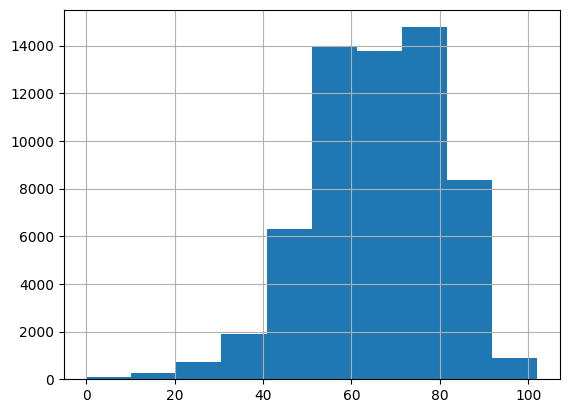

In [11]:
one['Age_Enc_Date1'].hist()

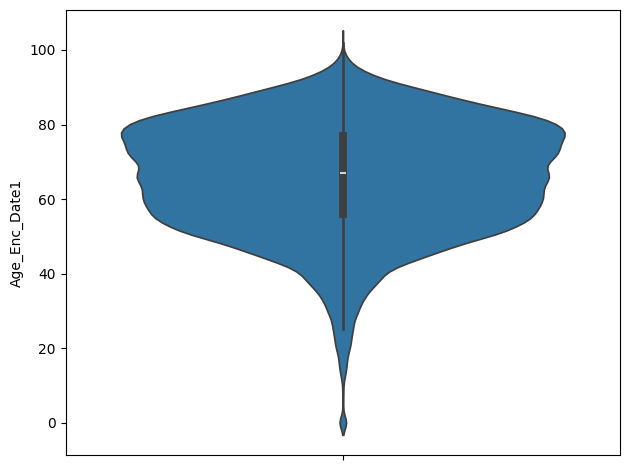

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(y=one['Age_Enc_Date1'])

plt.ylabel('Age_Enc_Date1')
plt.tight_layout()
plt.show()

In [13]:
one['Age_Enc_Date1'].describe()

count    61026.000000
mean        65.751778
std         14.935261
min          0.000000
25%         56.000000
50%         67.000000
75%         77.000000
max        102.000000
Name: Age_Enc_Date1, dtype: float64

### 2.1.1 Compare "age_group" vs "age_enc_Date1"

       Age_Group  Age_Enc_Date1  diff
00-09         53            108   -55
10-19        122            208   -86
20-29        476            668  -192
30-39       1204           1740  -536
40-49       3570           5524 -1954
50-59       9176          12280 -3104
60-69      13280          13630  -350
70-79      14085          14712  -627
80-89      12571          10422  2149
90-99       5792           1730  4062
_100+        695              4   691


<Axes: >

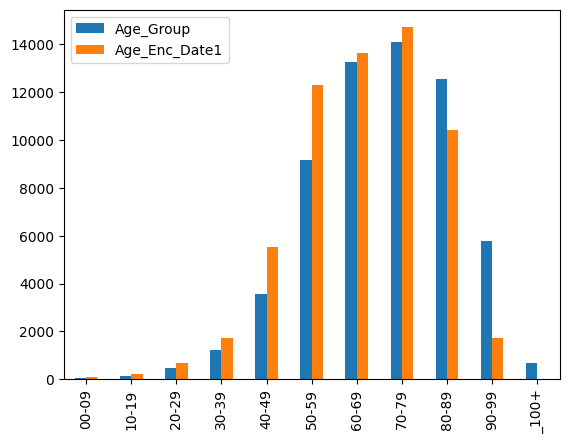

In [14]:

bins = [0,10,20,30,40,50,60,70,80,90,100,110]
labels = ["00-09","10-19","20-29","30-39","40-49","50-59",
          "60-69","70-79","80-89","90-99","_100+"]

comp = pd.DataFrame({
    "Age_Group": one["Age_Group"].value_counts().reindex(labels),
    "Age_Enc_Date1": pd.cut(one["Age_Enc_Date1"], bins=bins, right=False,
                            labels=labels).value_counts().reindex(labels),
})
comp["diff"] = comp["Age_Group"] - comp["Age_Enc_Date1"]
print(comp)
comp[["Age_Group","Age_Enc_Date1"]].plot.bar()

In [15]:
bins = [0,10,20,30,40,50,60,70,80,90,100,110]
labels = ["00-09","10-19","20-29","30-39","40-49","50-59",
          "60-69","70-79","80-89","90-99","_100+"]

### 2.1.1A Check if "Age_Group" is the matching variable

<Axes: xlabel='Age_Group'>

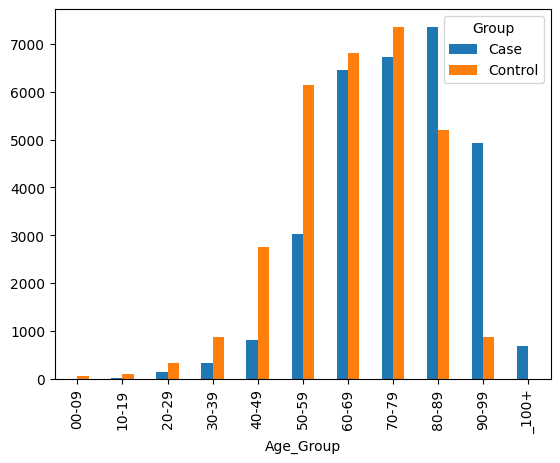

In [16]:
ct_group = pd.crosstab(one["Age_Group"], one["Group"]).reindex(labels)

ct_group.plot.bar()

### 2.1.1B Check if "Age_Enc_Date1" is a matching variable 

In [17]:
age_enc = pd.cut(one["Age_Enc_Date1"], bins=bins, right=False, labels=labels)
ct_enc   = pd.crosstab(age_enc,          one["Group"]).reindex(labels)

ct_enc

Group,Case,Control
Age_Enc_Date1,,
00-09,54,54
10-19,104,104
20-29,334,334
30-39,870,870
40-49,2762,2762
50-59,6140,6140
60-69,6815,6815
70-79,7356,7356
80-89,5211,5211


<Axes: xlabel='Age_Enc_Date1'>

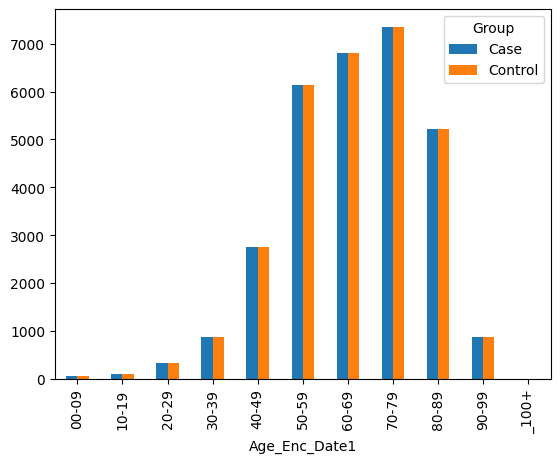

In [18]:
ct_enc.plot.bar()

#### Conclusion: 
- **"Age_Enc_Date1"** is one of the matching variable.
- --> will use this variable to regroup `Age` into few categories

### 2.1.2 Regroup "Age_Enc_Date1" into "Age_combine"

In [19]:
one["Age_combine"] = pd.cut(
    one["Age_Enc_Date1"],
    bins=[-np.inf, 30, 50, 70, 80, np.inf], right=False,
    labels=["less_than_30", "from_30_to_50", "from_50_to_70",
            "from_70_to_80", "more_than_80"],
).astype("object")

print(pd.crosstab(one["Age_combine"], one["Group"], margins=True))
print("missing:", one["Age_combine"].isna().sum())

Group           Case  Control    All
Age_combine                         
from_30_to_50   3632     3632   7264
from_50_to_70  12955    12955  25910
from_70_to_80   7356     7356  14712
less_than_30     492      492    984
more_than_80    6078     6078  12156
All            30513    30513  61026
missing: 0


## 2.2 RACE

In [20]:
# demographics, matching the BMI notebook's versions
race_map = {2: "white", 1: "black"}
one["Race_Cat_combine"] = one["Race_Cat"].map(race_map).fillna("others")

pd.crosstab(one["Race_Cat_combine"], one["Group"], margins=True)

Group,Case,Control,All
Race_Cat_combine,,,
black,8630,8630,17260
others,3664,3664,7328
white,18219,18219,36438
All,30513,30513,61026


## 2.3 SEX

In [21]:
pd.crosstab(one["sex"], one["Group"], margins=True)

Group,Case,Control,All
sex,,,
F,26928,26928,53856
M,3585,3585,7170
All,30513,30513,61026


## 2.4 Check again for demographic vars

In [22]:
DEMO = ["sex", "Race_Cat_combine", "Age_combine"]

for c in DEMO:
    counts = pd.crosstab(one[c], one["osteo_label"], margins=True)
    counts = counts.mask((counts < 5) & (counts > 0))          # small-cell suppression
    byrow = pd.crosstab(one[c], one["osteo_label"], normalize="index").round(4)

    print(f"\n===== {c} =====")
    print(counts)
    print("\nrow % — share of each level that is a case:")
    print(byrow)


===== sex =====
osteo_label      0      1    All
sex                             
F            26928  26928  53856
M             3585   3585   7170
All          30513  30513  61026

row % — share of each level that is a case:
osteo_label    0    1
sex                  
F            0.5  0.5
M            0.5  0.5

===== Race_Cat_combine =====
osteo_label           0      1    All
Race_Cat_combine                     
black              8630   8630  17260
others             3664   3664   7328
white             18219  18219  36438
All               30513  30513  61026

row % — share of each level that is a case:
osteo_label         0    1
Race_Cat_combine          
black             0.5  0.5
others            0.5  0.5
white             0.5  0.5

===== Age_combine =====
osteo_label        0      1    All
Age_combine                       
from_30_to_50   3632   3632   7264
from_50_to_70  12955  12955  25910
from_70_to_80   7356   7356  14712
less_than_30     492    492    984
more_than_80

# 3. Variable list

In [23]:
GROUPS = {
    "demographics": ["sex", "Race_Cat_combine", "Age_combine"],

    "continuous":   ["BMI_Avg"],

    "behavioral":   ["Alcohol_Prior", "Tobacco_Prior"],

    "drugs":        ["Drug_antipsych_prior", "Drug_Estrogens_prior",
                     "Drug_Glucocorticoids_prior", "Drug_Nsaids_prior",
                     "Drug_Opiates_prior", "Drug_Thiazide_prior",
                     "Drug_Loop_Diuretic_Prior", "Drug_Pp_inhibitors_prior",
                     "Drug_Progesterone_prior", "Drug_Seizure_prior",
                     "Drug_Ssris_prior", "Drug_Tc_antidepress_prior"],

    "diseases":     ["HeartDisease_Prior", "Liver_Prior", "PulmDisease_Prior",
                     "CNS_Disease_Prior", "Malignancy_Prior"],

    "hyponatremia": ["Hyponatremia_Prior", "Chronic_Hyponatremia",
                     "Recent_Hyponatremia"], 
    "calcium_sodium": ["Calcium_Closest_Osteo", "Sodium_Closest_Osteo", 
                       "Calcium_Avg_Prior", "Sodium_Avg_Prior", "Sodium_Worst_Prior"],
    "ever_worst": ['Calcium_Avg_Ever', 'Sodium_Avg_Ever','Sodium_Worst_Ever']
}

KEYS = ["Strata", "osteo_label"]

In [24]:
import yaml

cfg = yaml.safe_load(open("config_ml.yaml"))

KEYS = cfg["keys"]
GROUPS = {name: g["columns"] for name, g in cfg["groups"].items()}

In [25]:
KEYS

['Strata', 'osteo_label']

In [26]:
GROUPS

{'demographics': ['sex', 'Race_Cat_combine', 'Age_combine'],
 'continuous': ['BMI_Avg'],
 'behavioral': ['Alcohol_Prior', 'Tobacco_Prior'],
 'drugs': ['Drug_antipsych_prior',
  'Drug_Estrogens_prior',
  'Drug_Glucocorticoids_prior',
  'Drug_Nsaids_prior',
  'Drug_Opiates_prior',
  'Drug_Thiazide_prior',
  'Drug_Loop_Diuretic_Prior',
  'Drug_Pp_inhibitors_prior',
  'Drug_Progesterone_prior',
  'Drug_Seizure_prior',
  'Drug_Ssris_prior',
  'Drug_Tc_antidepress_prior'],
 'diseases': ['HeartDisease_Prior',
  'Liver_Prior',
  'PulmDisease_Prior',
  'CNS_Disease_Prior',
  'Malignancy_Prior'],
 'hyponatremia': ['Hyponatremia_Prior',
  'Chronic_Hyponatremia',
  'Recent_Hyponatremia'],
 'calcium_sodium': ['Calcium_Closest_Osteo',
  'Sodium_Closest_Osteo',
  'Calcium_Avg_Prior',
  'Sodium_Avg_Prior',
  'Sodium_Worst_Prior'],
 'ever_worst': ['Calcium_Avg_Ever', 'Sodium_Avg_Ever', 'Sodium_Worst_Ever']}

In [27]:
LAB_COLS = GROUPS["calcium_sodium"] + GROUPS["ever_worst"]
LAB_COLS


['Calcium_Closest_Osteo',
 'Sodium_Closest_Osteo',
 'Calcium_Avg_Prior',
 'Sodium_Avg_Prior',
 'Sodium_Worst_Prior',
 'Calcium_Avg_Ever',
 'Sodium_Avg_Ever',
 'Sodium_Worst_Ever']

In [28]:
ALL_VARS = [c for cols in GROUPS.values() for c in cols]

missing = [c for c in ALL_VARS if c not in one.columns]
assert not missing, f"not in df: {missing}"
assert not set(KEYS) & set(ALL_VARS), "keys must not be features"
assert len(ALL_VARS) == len(set(ALL_VARS)), "duplicate column"

print(len(ALL_VARS), "feature columns")
print({g: len(cols) for g, cols in GROUPS.items()})

34 feature columns
{'demographics': 3, 'continuous': 1, 'behavioral': 2, 'drugs': 12, 'diseases': 5, 'hyponatremia': 3, 'calcium_sodium': 5, 'ever_worst': 3}


In [29]:
print(one[ALL_VARS].dtypes.value_counts())

int64      22
float64     9
str         2
object      1
Name: count, dtype: int64


# 4. Data preprocessing for numeric variables

For the numeric variables, I converted them into categorical variables. The main purpose of this convertion is to help `Logistic Regression` learn easier in the next step, or to help `Random Forest` split faster with binary variables when building decision trees. 


To do this convertion, I created new variables: by `discretize` and create `presence/absence` variables


- step 1: `discretize`, converting these continuous variables into categorical variables by discretizing them. 
    - Here I applied `qcut` function in Python, and use 10 bins (thus termed "decile"), and may not have the same number of observations in each bin. All the variables with 'decile' in variable names are the products of this step
    
- step 2: creating `presence/absence` variables to these numeric variables. All the variables with 'cat' in variable names are the products of this step


Two lab columns hold continuous measurements: calcium and sodium.
They have a lot of missing values, and the missingness is meaningful —a blank means the test was never ordered, not that the value is unknown-but-normal.

So each raw column is replaced by two columns that separate those two facts:
-   `*_measured`     : was this test done at all?          (1 = yes, 0 = never measured)
-   `*_decile`  : if done, was the value high or low? (0-9, ranked into ten equal-sized bins, including missing values)

Splitting them this way means a model can learn from "never tested" and from "tested, and the value was low" as separate signals instead of confusing the two.

**`decile`**: rank into 10 bins holding equal NUMBERS of patients.

**`qcut`** cuts on quantiles, so each bin gets ~10% of patients but the value ranges differ in width. Blanks stay blank here and are filled below.

* **Missingness in the encoding:** Important note here: Missing labs are coded as decile 0, so lab deciles mix "not measured" with low values.

In [30]:
for col in LAB_COLS:
    # presence/absence: 1 if a measurement exists, 0 if the cell is blank
    one[col + "_measured"] = one[col].notna().astype(int)
   
    one[col + "_decile"] = pd.qcut(one[col], 10, labels=False, duplicates="drop")

DECILE_COLS = [c + "_decile" for c in LAB_COLS]
MEASURED_COLS    = [c + "_measured"    for c in LAB_COLS]

del GROUPS["calcium_sodium"]
GROUPS["labs_decile"]   = DECILE_COLS
GROUPS["labs_measured"] = MEASURED_COLS

In [31]:


# Patients with no measurement have no decile. Fill them with 0 so the column is numeric.
# Caveat worth knowing: this puts "never tested" in the same bin as "lowest measured value".
# The *_measured column is what lets you tell those two groups apart afterwards.
one[DECILE_COLS] = one[DECILE_COLS].fillna(0).astype(int)

# The raw continuous columns are now REPLACED, not kept alongside.
# Keeping both would feed the same measurement into the model twice.
GROUPS["labs_decile"] = DECILE_COLS
GROUPS["labs_measured"]    = MEASURED_COLS

In [33]:
one.shape

(61026, 203)

In [34]:
for g, cols in GROUPS.items():
    bad = [c for c in cols if c in KEYS]
    if bad:
        print(g, "->", bad)
        GROUPS[g] = [c for c in cols if c not in KEYS]

ALL_VARS = [c for cols in GROUPS.values() for c in cols]
assert not set(KEYS) & set(ALL_VARS)
print(len(ALL_VARS), "feature columns")   # expect 30

45 feature columns


In [35]:
one[ALL_VARS].dtypes

sex                                   str
Race_Cat_combine                      str
Age_combine                        object
BMI_Avg                           float64
Alcohol_Prior                       int64
Tobacco_Prior                       int64
Drug_antipsych_prior                int64
Drug_Estrogens_prior                int64
Drug_Glucocorticoids_prior          int64
Drug_Nsaids_prior                   int64
Drug_Opiates_prior                  int64
Drug_Thiazide_prior                 int64
Drug_Loop_Diuretic_Prior            int64
Drug_Pp_inhibitors_prior            int64
Drug_Progesterone_prior             int64
Drug_Seizure_prior                  int64
Drug_Ssris_prior                    int64
Drug_Tc_antidepress_prior           int64
HeartDisease_Prior                  int64
Liver_Prior                         int64
PulmDisease_Prior                   int64
CNS_Disease_Prior                   int64
Malignancy_Prior                    int64
Hyponatremia_Prior                

## 4.1 Lab test coverage: pre-index vs full record

> **Key result.** Share of the 61,026 patients with at least one value for each lab (mean of the `_measured` flag, printed below).
>
> | Lab | Pre-index (`_Avg_Prior`) | Full record (`_Avg_Ever`, incl. post-index) |
> |---|---:|---:|
> | Calcium | **58.4%** (Calcium_Avg_Prior_measured)| **88.9%** (Calcium_Avg_Ever_measured) |
> | Sodium | **67.4%** (Sodium_Avg_Prior_measured) | **99.6%** (Sodium_Avg_Ever_measured) |

In [36]:
#the fraction of the 61,026 patients who had at least one value for that lab.
print(one[MEASURED_COLS].mean().round(3))          # share of patients who had each test

Calcium_Closest_Osteo_measured    0.583
Sodium_Closest_Osteo_measured     0.698
Calcium_Avg_Prior_measured        0.584
Sodium_Avg_Prior_measured         0.674
Sodium_Worst_Prior_measured       0.674
Calcium_Avg_Ever_measured         0.889
Sodium_Avg_Ever_measured          0.996
Sodium_Worst_Ever_measured        0.996
dtype: float64


# 5. Check distribution of calcium_sodium values

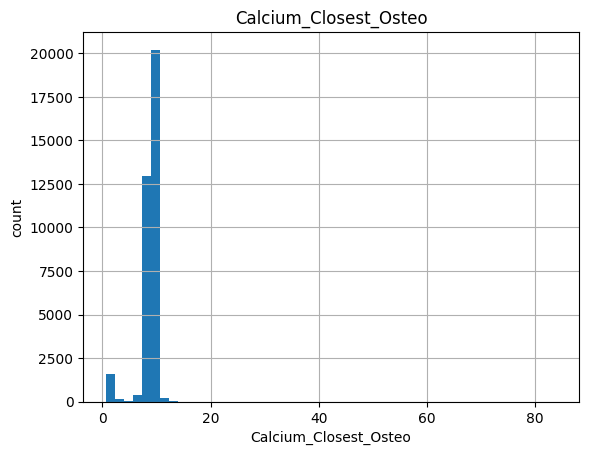

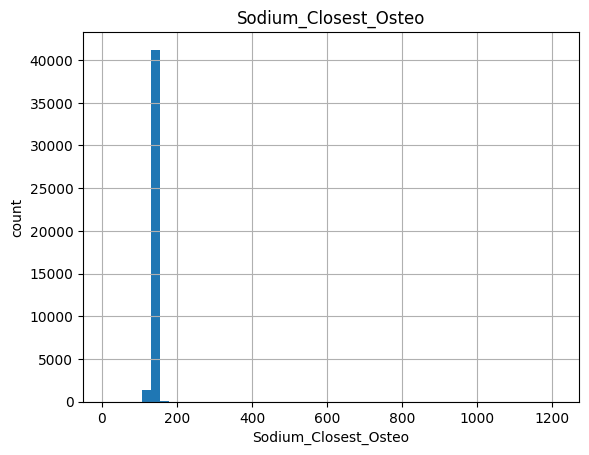

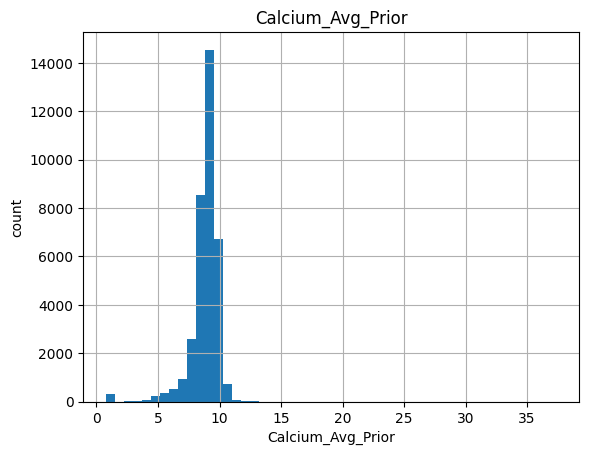

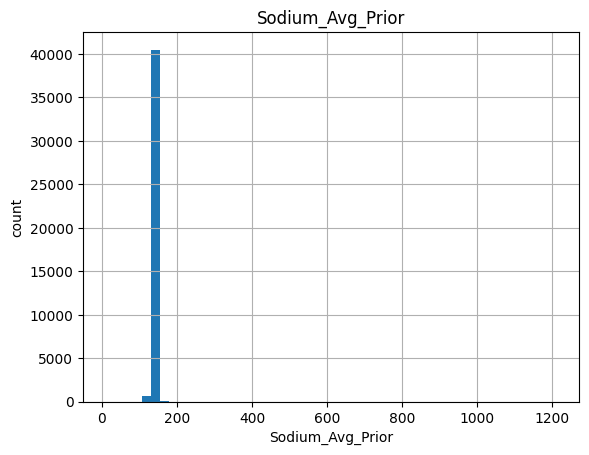

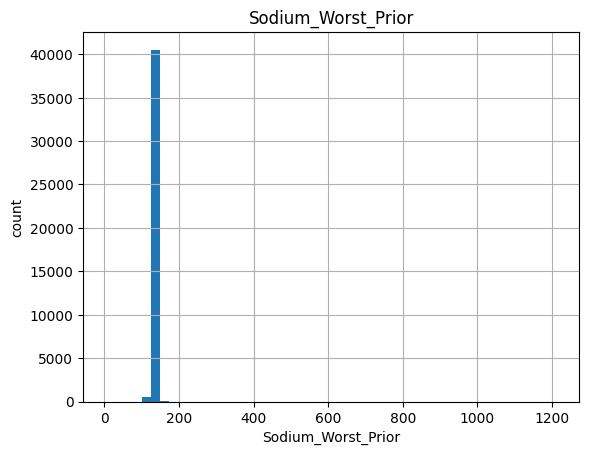

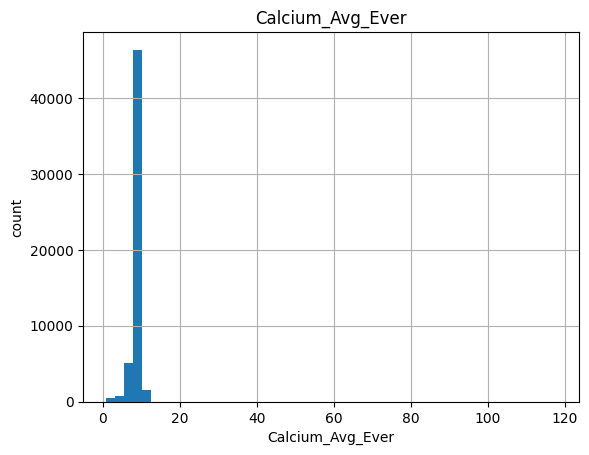

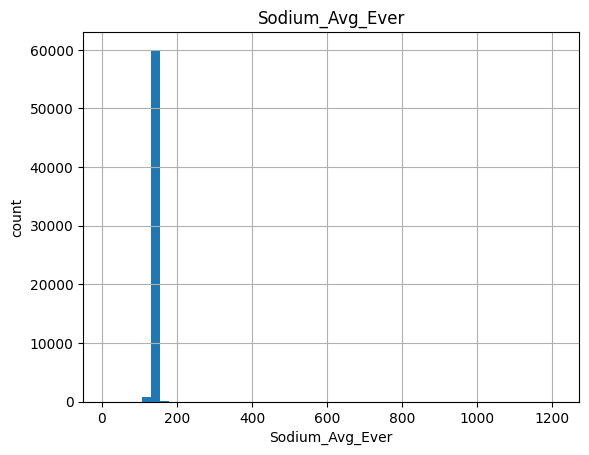

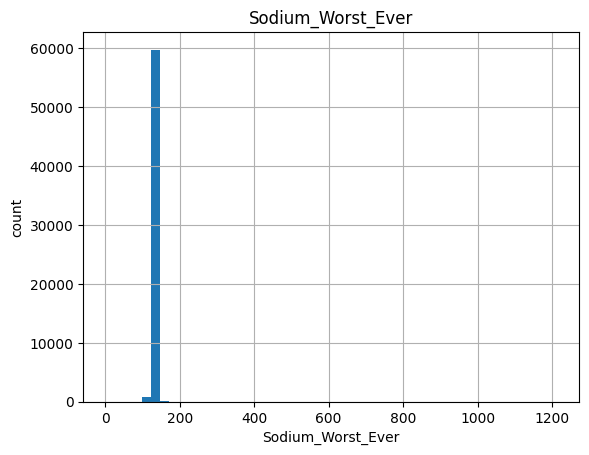

In [37]:
import matplotlib.pyplot as plt

for col in LAB_COLS:
    plt.figure()
    one[col].hist(bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

### Zoom into `Calcium_Avg_Prior` variable

<Axes: >

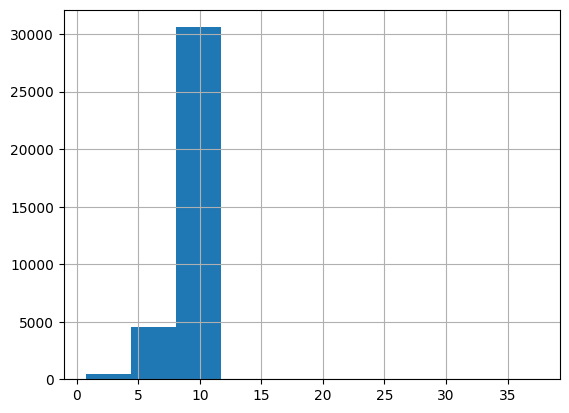

In [38]:
one['Calcium_Avg_Prior'].hist()

In [39]:
s = one['Calcium_Avg_Prior']

print(s.describe())
print()
print("zeros:", (s == 0).sum())
print("above 15:", (s > 15).sum())

count    35638.000000
mean         8.824595
std          1.220204
min          0.750000
25%          8.500000
50%          9.054545
75%          9.500000
max         37.400000
Name: Calcium_Avg_Prior, dtype: float64

zeros: 0
above 15: 5


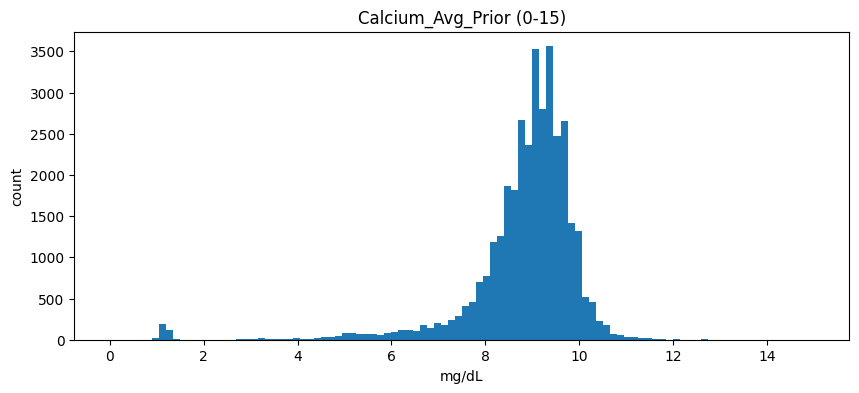

In [40]:
import matplotlib.pyplot as plt

s = one['Calcium_Avg_Prior']

plt.figure(figsize=(10, 4))
plt.hist(s, bins=100, range=(0, 15))
plt.title('Calcium_Avg_Prior (0-15)')
plt.xlabel('mg/dL')
plt.ylabel('count')
plt.show()

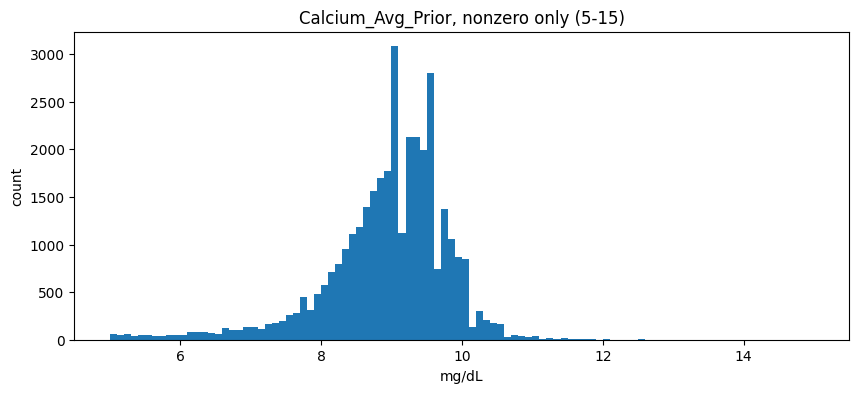

In [41]:
s = one['Calcium_Avg_Prior']
nonzero = s[s > 0]

plt.figure(figsize=(10, 4))
plt.hist(nonzero, bins=100, range=(5, 15))
plt.title('Calcium_Avg_Prior, nonzero only (5-15)')
plt.xlabel('mg/dL')
plt.ylabel('count')
plt.show()

In [42]:
s[s < 5].value_counts()

Calcium_Avg_Prior
1.190000    26
1.150000    24
1.210000    21
1.200000    21
1.160000    21
            ..
4.547778     1
1.136667     1
4.235000     1
4.736250     1
4.410000     1
Name: count, Length: 276, dtype: int64

In [43]:
s.isna().sum()

np.int64(25388)

In [44]:
s.isna().any() or np.isinf(s).any()

np.True_

In [45]:
q = pd.qcut(s, 10, labels=False)

print(q.value_counts(dropna=False).sort_index())

Calcium_Avg_Prior
0.0     3564
1.0     3564
2.0     3574
3.0     3560
4.0     3559
5.0     3723
6.0     4207
7.0     2760
8.0     3725
9.0     3402
NaN    25388
Name: count, dtype: int64


> `qcut` drops NaN silently: it fits the 10 bins on the ~35,600 rows that have values, and returns NaN for the rest.

> another risk of NaN is that ML models wont run at all and raise flag. But filling NaN with 0 has problems:
If the deciles are labeled 0–9, then bin 0 already means "lowest measured calcium." Filling NaN with 0 drops 25,388 never-tested patients into that same bin. The model can no longer distinguish "this patient has low calcium" from "this patient was never tested," because both are the number 0.

And those two groups are clinically opposite. Someone with a measured low calcium has a metabolic problem. Someone never tested is usually healthier — nobody ordered the panel.

# 6. Proportion of Missingness on case vs control

In [46]:
pd.crosstab(one['Calcium_Avg_Prior'].isna(), one['osteo_label'], normalize='columns')

osteo_label,0,1
Calcium_Avg_Prior,,
False,0.650968,0.516993
True,0.349032,0.483007


In [47]:
one[LAB_COLS].isna().sum()

Calcium_Closest_Osteo    25457
Sodium_Closest_Osteo     18446
Calcium_Avg_Prior        25388
Sodium_Avg_Prior         19893
Sodium_Worst_Prior       19893
Calcium_Avg_Ever          6792
Sodium_Avg_Ever            249
Sodium_Worst_Ever          249
dtype: int64

In [48]:
one[LAB_COLS].isna().sum()/one.shape[0]

Calcium_Closest_Osteo    0.417150
Sodium_Closest_Osteo     0.302265
Calcium_Avg_Prior        0.416019
Sodium_Avg_Prior         0.325976
Sodium_Worst_Prior       0.325976
Calcium_Avg_Ever         0.111297
Sodium_Avg_Ever          0.004080
Sodium_Worst_Ever        0.004080
dtype: float64

In [49]:
for col in LAB_COLS:
    print(col, "\n")
    print(pd.crosstab(one[col].isna(), one['osteo_label'], normalize='columns'))
    print("---")

Calcium_Closest_Osteo 

osteo_label                   0         1
Calcium_Closest_Osteo                    
False                  0.658277  0.507423
True                   0.341723  0.492577
---
Sodium_Closest_Osteo 

osteo_label                  0         1
Sodium_Closest_Osteo                    
False                 0.671878  0.723593
True                  0.328122  0.276407
---
Calcium_Avg_Prior 

osteo_label               0         1
Calcium_Avg_Prior                    
False              0.650968  0.516993
True               0.349032  0.483007
---
Sodium_Avg_Prior 

osteo_label              0         1
Sodium_Avg_Prior                    
False             0.663226  0.684823
True              0.336774  0.315177
---
Sodium_Worst_Prior 

osteo_label                0         1
Sodium_Worst_Prior                    
False               0.663226  0.684823
True                0.336774  0.315177
---
Calcium_Avg_Ever 

osteo_label              0         1
Calcium_Avg_Ever             

## Conclusion

- **Calcium is skewed; sodium is not.**
- Calcium has substantially higher missingness among cases than controls:
  - `Calcium_Closest_Osteo`: **+15 pp**
  - `Calcium_Avg_Prior`: **+13 pp**
- Sodium shows little difference in missingness between cases and controls:
  - `Sodium_Closest_Osteo`: **−5 pp**
  - `Sodium_Avg_Prior`: **−2 pp**
  - `Sodium_Worst_Prior`: **−2 pp**

| Column | Controls missing | Cases missing | Missingness gap |
|---|---:|---:|---:|
| `Calcium_Closest_Osteo` | 34.2% | 49.3% | **+15 pp** |
| `Calcium_Avg_Prior` | 34.9% | 48.3% | **+13 pp** |
| `Sodium_Closest_Osteo` | 32.8% | 27.6% | −5 pp |
| `Sodium_Avg_Prior` | 33.7% | 31.5% | −2 pp |
| `Sodium_Worst_Prior` | 33.7% | 31.5% | −2 pp |

# 7. Save features

In [50]:
one.columns

Index(['_Imputation_', 'patientid', 'sex', 'Race', 'Ethnicity', 'DOB',
       'ENC_DATE1', 'ENC_DATE2', 'Enc_Mth_Diff', 'Enc_Day_Diff',
       ...
       'Sodium_Avg_Prior_measured', 'Sodium_Avg_Prior_decile',
       'Sodium_Worst_Prior_measured', 'Sodium_Worst_Prior_decile',
       'Calcium_Avg_Ever_measured', 'Calcium_Avg_Ever_decile',
       'Sodium_Avg_Ever_measured', 'Sodium_Avg_Ever_decile',
       'Sodium_Worst_Ever_measured', 'Sodium_Worst_Ever_decile'],
      dtype='str', length=203)

In [51]:
one.shape

(61026, 203)

In [52]:
one.to_csv(DATA_DIR / "osteo_features.csv", index=False)